# 03 — Train the Dynamic (Transformer) Branch on Real MOBISIG Data

Trains `sigverify.models.dynamic_branch.DynamicStrokeEncoder` on the real MOBISIG
finger-drawn online signature dataset, with a writer-disjoint train/val split.
The stroke encoder is lightweight (no CNN backbone), so this runs considerably
faster than the static-branch notebook even on CPU — but this notebook still
uses a writer subset and a short epoch count to keep runtime bounded on
constrained hardware.

For a full production run use `scripts/train_dynamic.py` with the default config.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sigverify.data.datasets import DynamicStrokeTripletDataset, split_writers, load_manifest
from sigverify.models.dynamic_branch import DynamicStrokeEncoder
from sigverify.models.losses import CombinedEmbeddingLoss
from sigverify.utils.metrics import verification_report
from sigverify.utils.seed import set_seed, get_device
from sigverify.utils.data_utils import safe_batch_size_and_drop_last

set_seed(42)
device = get_device("cpu")
DYNAMIC_MANIFEST = REPO_ROOT / "data/processed/real/mobisig_dynamic_manifest.jsonl"
ARTIFACTS = REPO_ROOT / "notebooks/artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
dynamic_records = load_manifest(DYNAMIC_MANIFEST)
print("Device:", device)
print("Total real MOBISIG samples available:", len(dynamic_records))


Device: cpu
Total real MOBISIG samples available: 975


## Writer-disjoint train/val split (a subset of real MOBISIG writers, for runtime)

In [2]:
RESAMPLE_POINTS = 256
EPOCHS = 4
BATCH_SIZE = 16
NUM_WRITERS = 8   # subset of the 15 converted writers, to keep this notebook's runtime short

all_writers = sorted({r["writer_id"] for r in dynamic_records}, key=lambda w: int(w.replace("mobisig_user", "")))
subset_writers = set(all_writers[:NUM_WRITERS])
train_writers, val_writers = split_writers(DYNAMIC_MANIFEST, val_fraction=0.25, seed=42)
train_writers = train_writers & subset_writers
val_writers = val_writers & subset_writers
if not val_writers:
    ordered = sorted(subset_writers)
    train_writers, val_writers = set(ordered[:-1]), set(ordered[-1:])

common_kwargs = {"resample_points": RESAMPLE_POINTS, "normalize": "zscore"}
train_ds = DynamicStrokeTripletDataset(DYNAMIC_MANIFEST, writer_ids=train_writers, **common_kwargs)
val_ds = DynamicStrokeTripletDataset(DYNAMIC_MANIFEST, writer_ids=val_writers, **common_kwargs)

train_bs, train_drop_last = safe_batch_size_and_drop_last(len(train_ds), BATCH_SIZE)
val_bs, _ = safe_batch_size_and_drop_last(len(val_ds), BATCH_SIZE)
train_loader = DataLoader(train_ds, batch_size=train_bs, shuffle=True, drop_last=train_drop_last)
val_loader = DataLoader(val_ds, batch_size=val_bs, shuffle=False)

print(f"Train writers: {len(train_writers)} | Val writers: {len(val_writers)}")
print(f"Train triplets: {len(train_ds)} | Val triplets: {len(val_ds)}")


Train writers: 5 | Val writers: 3
Train triplets: 225 | Val triplets: 135


## Model, loss, optimizer

In [3]:
model = DynamicStrokeEncoder(
    input_dim=7, hidden_dim=128, num_layers=2, num_heads=4, embedding_dim=128,
    encoder="transformer", dropout=0.1,
).to(device)
criterion = CombinedEmbeddingLoss(contrastive_margin=1.0, triplet_margin=0.3)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)

num_params = sum(p.numel() for p in model.parameters())
print(f"DynamicStrokeEncoder (transformer): {num_params:,} parameters")


DynamicStrokeEncoder (transformer): 480,512 parameters


## Training loop — real loss + real EER/AUC each epoch

In [4]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    genuine, forged = [], []
    for a, p, n in loader:
        a, p, n = a.to(device), p.to(device), n.to(device)
        e_a, _ = model(a)
        e_p, _ = model(p)
        e_n, _ = model(n)
        genuine.append(model.similarity(e_a, e_p).cpu().numpy())
        forged.append(model.similarity(e_a, e_n).cpu().numpy())
    genuine = (np.concatenate(genuine) + 1) / 2
    forged = (np.concatenate(forged) + 1) / 2
    return verification_report(genuine, forged)

history = {"train_loss": [], "val_eer": [], "val_auc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for a, p, n in train_loader:
        a, p, n = a.to(device), p.to(device), n.to(device)
        optimizer.zero_grad()
        e_a, _ = model(a)
        e_p, _ = model(p)
        e_n, _ = model(n)
        loss = criterion(e_a, e_p, e_n)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    metrics = evaluate(val_loader)
    history["train_loss"].append(running_loss / max(1, len(train_loader)))
    history["val_eer"].append(metrics["eer"])
    history["val_auc"].append(metrics["roc_auc"])
    print(f"epoch {epoch}/{EPOCHS} | train_loss={history['train_loss'][-1]:.4f} "
          f"| val_eer={metrics['eer']:.4f} | val_auc={metrics['roc_auc']:.4f}")

torch.save(model.state_dict(), ARTIFACTS / "dynamic_branch_mobisig.pt")
print("\nSaved:", ARTIFACTS / "dynamic_branch_mobisig.pt")


epoch 1/4 | train_loss=0.5486 | val_eer=0.3000 | val_auc=0.7608


epoch 2/4 | train_loss=0.3174 | val_eer=0.2852 | val_auc=0.7901


epoch 3/4 | train_loss=0.2532 | val_eer=0.2444 | val_auc=0.8184


epoch 4/4 | train_loss=0.1861 | val_eer=0.2963 | val_auc=0.7736

Saved: D:\AI Based Signature Identification system\notebooks\artifacts\dynamic_branch_mobisig.pt


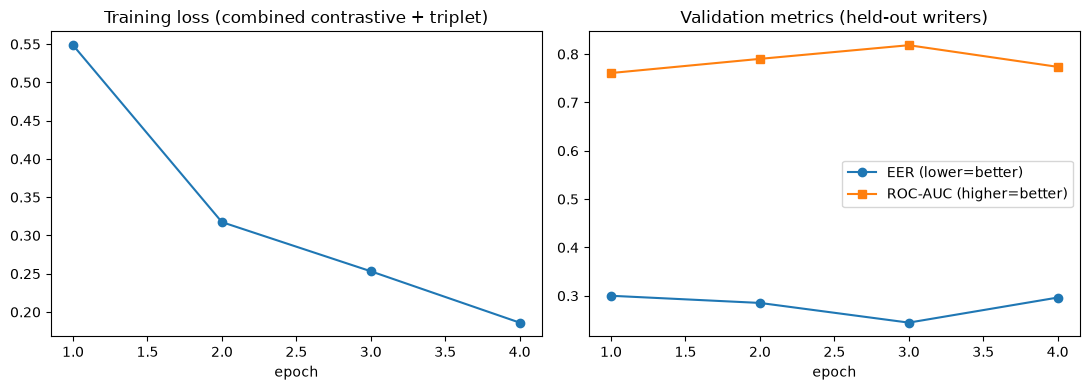

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, EPOCHS + 1), history["train_loss"], marker="o")
axes[0].set_title("Training loss (combined contrastive + triplet)")
axes[0].set_xlabel("epoch")
axes[1].plot(range(1, EPOCHS + 1), history["val_eer"], marker="o", label="EER (lower=better)")
axes[1].plot(range(1, EPOCHS + 1), history["val_auc"], marker="s", label="ROC-AUC (higher=better)")
axes[1].set_title("Validation metrics (held-out writers)")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.show()


## Attention weights: which strokes did the model weight most heavily?

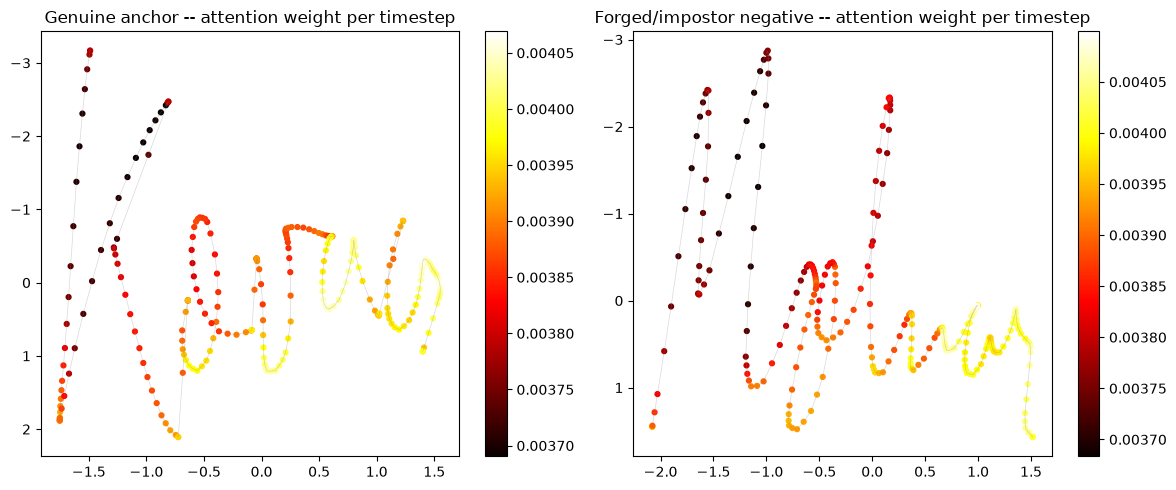

In [6]:
model.eval()
anchor_seq, positive_seq, negative_seq = val_ds[0]
with torch.no_grad():
    _, attn_genuine = model(anchor_seq.unsqueeze(0).to(device))
    _, attn_forged = model(negative_seq.unsqueeze(0).to(device))

attn_genuine = attn_genuine.squeeze(0).cpu().numpy()
attn_forged = attn_forged.squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x, y = anchor_seq[:, 0].numpy(), anchor_seq[:, 1].numpy()
sc = axes[0].scatter(x, y, c=attn_genuine, cmap="hot", s=12)
axes[0].plot(x, y, color="gray", alpha=0.3, linewidth=0.5)
axes[0].invert_yaxis()
axes[0].set_title("Genuine anchor -- attention weight per timestep")
plt.colorbar(sc, ax=axes[0])

x2, y2 = negative_seq[:, 0].numpy(), negative_seq[:, 1].numpy()
sc2 = axes[1].scatter(x2, y2, c=attn_forged, cmap="hot", s=12)
axes[1].plot(x2, y2, color="gray", alpha=0.3, linewidth=0.5)
axes[1].invert_yaxis()
axes[1].set_title("Forged/impostor negative -- attention weight per timestep")
plt.colorbar(sc2, ax=axes[1])
plt.tight_layout()
plt.show()


## DTW-based stroke deviation: genuine pair vs. forged pair

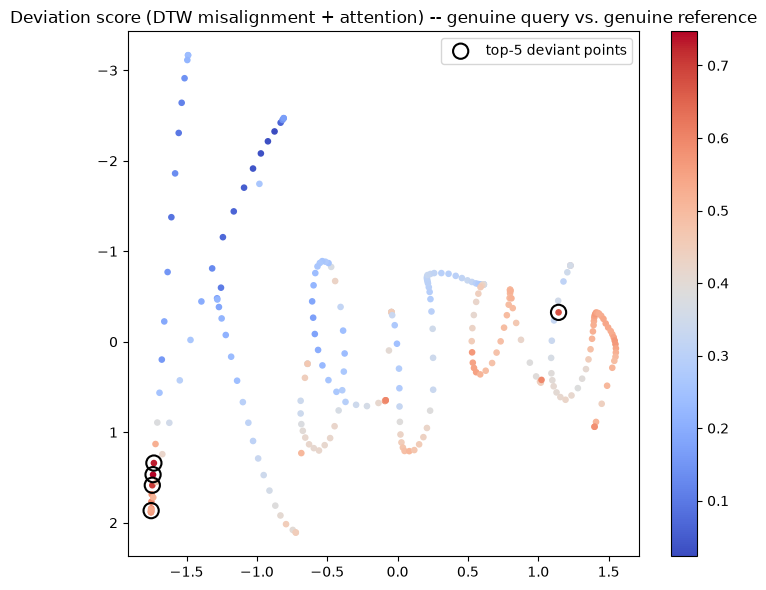

Top deviant timestep indices: [15, 14, 16, 204, 20]


In [7]:
from sigverify.explainability.attention_viz import stroke_deviation_scores, top_k_deviant_indices

query_seq_np = anchor_seq.numpy()
reference_seq_np = positive_seq.numpy()
deviation = stroke_deviation_scores(query_seq_np, reference_seq_np, attn_genuine)
top_idx = top_k_deviant_indices(deviation, k=5)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(query_seq_np[:, 0], query_seq_np[:, 1], c=deviation, cmap="coolwarm", s=14)
ax.scatter(query_seq_np[top_idx, 0], query_seq_np[top_idx, 1], facecolors="none", edgecolors="black", s=120, linewidths=1.5, label="top-5 deviant points")
ax.invert_yaxis()
ax.legend()
ax.set_title("Deviation score (DTW misalignment + attention) -- genuine query vs. genuine reference")
plt.colorbar(sc, ax=ax)
plt.tight_layout()
plt.show()

print("Top deviant timestep indices:", top_idx.tolist())


## Summary

Trained on **real** MOBISIG finger-drawn signatures with a writer-disjoint
validation split -- loss falls, EER/AUC move, and the attention + DTW deviation
visualizations line up with the explainability module used in production
(`sigverify.explainability`). Next: `04_fusion_and_evaluation.ipynb` combines both
real-data-trained branches through the fusion network and runs the full
end-to-end verification pipeline.
